Epoch 1000/10000 - Loss: 0.8255830407142639
Epoch 2000/10000 - Loss: 0.8443099856376648
Epoch 3000/10000 - Loss: 0.7679235339164734
Epoch 4000/10000 - Loss: 0.7952612638473511
Epoch 5000/10000 - Loss: 0.7694919109344482
Epoch 6000/10000 - Loss: 0.796403706073761
Epoch 7000/10000 - Loss: 0.7456588745117188
Epoch 8000/10000 - Loss: 0.7862077951431274
Epoch 9000/10000 - Loss: 0.7584503293037415
Epoch 10000/10000 - Loss: 0.772309422492981


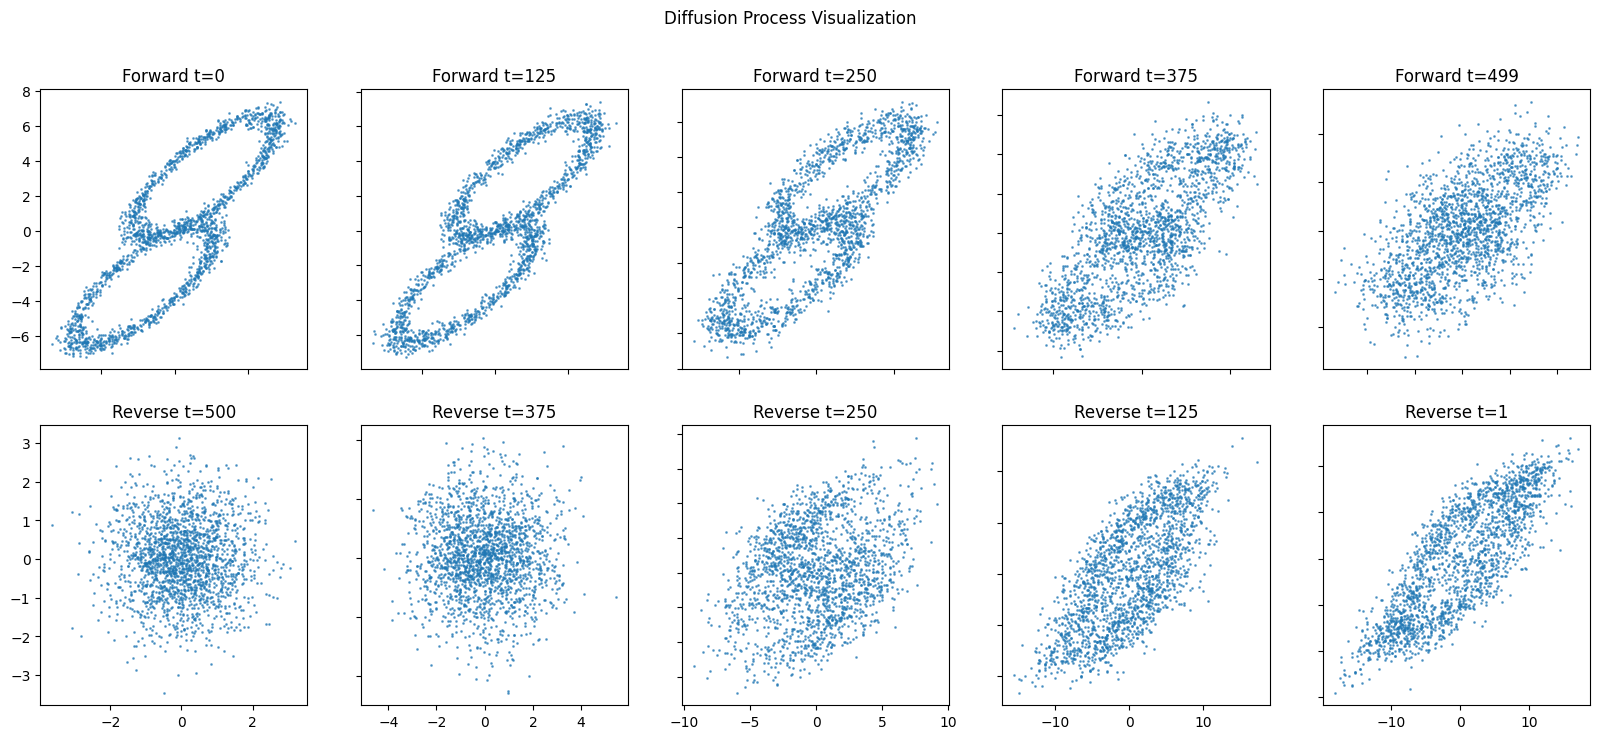

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pickle

# Set device for training (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define the size of the time embedding
time_embedding_size = 128

# Sinusoidal Embedding class
class SinusoidalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0, device=None):
        super().__init__()
        self.size = size
        self.scale = scale
        self.device = device

    def forward(self, x: torch.Tensor):
        x = x * self.scale
        half_size = self.size // 2
        emb = torch.log(torch.tensor([10000.0], device=self.device)) / (half_size - 1)
        emb = torch.exp(-emb * torch.arange(half_size, device=self.device))
        emb = x.unsqueeze(-1) * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        return emb

    def __len__(self):
        return self.size

# Instantiate the sinusoidal embedding with the device
sin_embedding = SinusoidalEmbedding(time_embedding_size, device=device)

# Noise Predictor model
class NoisePredictor(nn.Module):
    def __init__(self, time_embedding_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2 + time_embedding_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 2),
        )

    def forward(self, x, t_embedding):
        t_embedding = t_embedding.view(t_embedding.size(0), -1)
        x = torch.cat((x, t_embedding), dim=1)
        return self.model(x)

# Initialize the model and optimizer
noise_predictor = NoisePredictor(time_embedding_size).to(device)
optimizer = optim.Adam(noise_predictor.parameters(), lr=1e-4)

# Load the data (replace 'hw4_p1.pkl' with the actual path to your dataset)
with open('hw4_p1.pkl', 'rb') as f:
    target_distribution_data = pickle.load(f)
target_distribution = torch.Tensor(target_distribution_data).to(device)

# Training hyperparameters
T = 500
beta = torch.linspace(1e-3, 1e-1, T).to(device) ** 2
alpha = (1 - beta).to(device)
alpha_bar = torch.cumprod(alpha, dim=0).to(device)
sigma = torch.sqrt((1 - alpha_bar) / (1 - alpha) * beta).to(device)

# Training loop
num_epochs = 10000  # Adjust the number of epochs
for epoch in range(num_epochs):
    # Sample from the dataset
    x0_indices = torch.randint(0, target_distribution.size(0), (2000,))
    x0 = target_distribution[x0_indices].to(device)
    # Generate time t
    t_indices = torch.randint(0, T, (2000,)).to(device)
    t = t_indices + 1
    # Sample noise
    epsilon = torch.randn(2000, 2, device=device)
    # Calculate forward diffusion xt
    alpha_bar_t = alpha_bar[t_indices]
    alpha_bar_t = alpha_bar_t.unsqueeze(1)
    xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * epsilon
    # Calculate time embeddings
    t_embedding = sin_embedding(t.float())
    # Calculate Loss
    noise_pred = noise_predictor(xt, t_embedding)
    loss = torch.mean((epsilon - noise_pred) ** 2)
    # Perform gradient descent
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Print progress
    if (epoch+1) % 1000 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item()}")

# Save the trained model
torch.save(noise_predictor.state_dict(), 'noise_predictor.pth')

# Define the reverse diffusion process
def reverse_process(noise_predictor, steps=T, device=device):
    noise_predictor.eval()
    xt = torch.randn((2000, 2), device=device)
    for t in reversed(range(steps)):
        current_step = t
        t_tensor = torch.full((2000,), current_step, dtype=torch.long, device=device)
        t_embedding = sin_embedding(t_tensor.float())
        epsilon = torch.randn((2000, 2), device=device) if current_step > 0 else torch.zeros_like(xt)
        noise_pred = noise_predictor(xt, t_embedding)
        xt = (xt - (1 - alpha[current_step]) / torch.sqrt(1 - alpha_bar[current_step]) * noise_pred) / torch.sqrt(alpha[current_step])
        xt = xt + sigma[current_step] * epsilon
    return xt

# Plotting function
def plot_samples(samples, title):
    plt.figure(figsize=(10, 5))
    plt.scatter(samples[:, 0], samples[:, 1], c='blue', alpha=0.6, s=10)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()

# Visualization functions

def visualize_diffusion_process(noise_predictor, target_distribution, alpha, alpha_bar, sigma, T, device, num_samples=2000):
    # Select time steps for visualization
    time_steps = [0, T//4, T//2, 3*T//4, T-1]  # T-1 is used instead of T to stay within bounds
    fig, axs = plt.subplots(2, len(time_steps), figsize=(20, 8))
    noise_predictor.eval()

    for i, t in enumerate(time_steps):
        # Forward diffusion from data to noise
        noise = torch.randn(num_samples, 2, device=device)
        forward_diffused = torch.sqrt(alpha_bar[t]) * target_distribution[:num_samples] + torch.sqrt(1 - alpha_bar[t]) * noise
        axs[0, i].scatter(forward_diffused[:, 0].cpu().detach().numpy(), forward_diffused[:, 1].cpu().detach().numpy(), s=1, alpha=0.6)
        axs[0, i].set_title(f"Forward t={t}")

        # Reverse diffusion from noise to data
        reversed_samples = reverse_process(noise_predictor, steps=t, device=device)
        axs[1, i].scatter(reversed_samples[:, 0].cpu().detach().numpy(), reversed_samples[:, 1].cpu().detach().numpy(), s=1, alpha=0.6)
        axs[1, i].set_title(f"Reverse t={T-t}")

    for ax in axs.flat:
        ax.label_outer()

    fig.suptitle('Diffusion Process Visualization')
    plt.show()

# Visualize the diffusion process
visualize_diffusion_process(noise_predictor, target_distribution, alpha, alpha_bar, sigma, T, device)